In [1]:
# Add module to path
import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['savefig.transparent'] = True
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from matplotlib.colors import TABLEAU_COLORS
from scipy.signal import convolve2d
from scipy.stats import norm

from darts.dartboards import generate_dartboard, DARTBOARD_CONSTANTS
from darts.stats import expected_score, std_score, gaussian_filter

In [3]:
board, _ = generate_dartboard(2048)
mm_per_pixel = 2*DARTBOARD_CONSTANTS['DARTBOARD_RADIUS_MM']/2048

## Maximising the probability of reaching checkout in N moves

The analysis up until now has concerned the maximisation of the expected value of the score from a single dart. For simplicity, let's define the random variable $X_i = s(Z_i)$ as the score obtained from the dart throw, with expected value $\mathbf{E}(X_i) = \mu$ and variance $\text{Var}(X_i) = \omega^2$. Also define the total score after $N$ throws as $S_N = \sum_{i=1}^{N}X_i$. The values of $\mu$ and $\omega$ will depend on the point at which Alice is aiming $p$, and Alice's skill level parameterised by $\sigma$ (which is for now assumed to be fixed).  Due to linearity of expectation, the expected score from $N$ darts thrown consecutively is $N$ multipled by the single dart expected score:

$$
\mathbf{E}\left(\sum_{i=1}^{N}X_i\right)=\sum_{i=1}^{N}E\left(X_i\right)=N\mathbf{E}\left(X_1\right)
$$

Now, suppose instead that we wish to maximise a different quantity - the probability after $N$ darts of achieving a score of at least K:

$$
F(N, K)\equiv\mathbf{P}\left(\sum_{i=1}^{N}X_i > K\right)
$$


Why consider this alternative optimization function $F(N, K)$? Suppose Alice is playing against an opponent (Bob) with a known skill level, and so is expected to reach the checkout stage after $N$ darts. Alice wants to make sure that she is also in checkout range at the same time that Bob is, in order to apply pressure him. As well as trying to maximise the score of each dart, Alice will need to take account of the variance of the score of each dart - throwing at a high scoring region with a large variance comes with a significant probability of getting unlucky, allowing Bob to get ahead and have several chances at checking out.

#### Hoeffding inequality

There are ways to bound the function $F(N,K)$ - for example, by using [Hoeffding's inequality](https://en.wikipedia.org/wiki/Hoeffding%27s_inequality), and noting that $0\leq X_i \leq 60$, we can show that:

$$
\mathbf{P}\left[S_N \geq N\mu + t\right]\leq \exp{\left[\frac{-t^2}{1800N}\right]}.
$$

In other words, the probability that after $N$ throws Alice has exceeded the expected score of $N\mu$ by $t$ points is bounded above by an exponentially decreasing function of $t^2/N$. For example, assume Alice has an expected single-dart score of $15$ points. Bob has a 1-dart expected score of $30$, so is expected to reach the checkout stage in about $16$ turns. After $16$ throws, Alice should expect to score $240$ points; the probability that she has in fact scored more than $461$ points (and therefore bringing her into checkout range) is bounded above by this inequality:

$$
\mathbf{P}\left(S_N \geq 461\right)\leq\exp{\left(\frac{-(461-240)^2}{1800*16}\right)}\approx0.18
$$

In [4]:
def hoeffding_bound(total, N, mu):
    t = total - N*mu
    return np.exp(-t*t/(1800*N))

In [5]:
hoeffding_bound(461, 16, 15)

0.1834399238498403

Unfortunately, this bound is only useful when considering players of vastly different skill levels (Bob is much better than Alice), so this does not give any great insight into strategies for players with comparable abilites. 

#### Central Limit Theorem

Instead, let's note that the Central Limit Theorem (CLT) can be applied to the total score after $N$ throws $S_N$, to give an approximation for its distribution:

$$
\lim_{N\rightarrow\infty}\mathbf{P}\left[\frac{S_N - N\mu}{\omega\sqrt{N}}\leq z\right] = \Phi(z)
$$

Rearranging to but this in a more familiar form:

$$
\begin{align}
\lim_{N\rightarrow\infty}F(N, K) &= \lim_{N\rightarrow\infty}\mathbf{P}\left(S_N>K\right) \\
&=1-\Phi\left[\frac{K-N\mu}{\omega\sqrt{N}}\right] \\
&= \Phi\left[\sqrt{N}\,\frac{\mu - k}{\omega}\right]
\end{align}
$$

where we have defined $k=K/N$. In words, this result says that the probability of scoring greater than $Nk$ points with $N$ darts (i.e. the expected score with a 1-dart average of $k$) is given by the Gaussian CDF $\Phi$, evaluated at the point $\sqrt{N}\frac{\mu-k}{\omega}$, in the limit as $N\rightarrow\infty$. In practice, Alice will only be throwing finitely many darts at the dartboard, so it needs to be investigated whether the approximation is valid for various $N$ (we won't be making the common mistake of assuming $30=\infty$!). 

### Testing the validity of the CLT approximation

In this section, we investigate some methods for improving the approximation given by the Central Limit Theorem, in order to get better estimates for the probability of scoring more than a certain total. If you are only interested in the application to a game of darts, feel free to skip this section!

The method for testing the validity of the approximation is as follows:
1. Choose a range of $\sigma$ values, parametrising Alice's skill level.
2. For each choice of $\sigma$, compute the optimal aim point on the dartboard Find the expected 1-dart distribution when aiming at this point, including the expected 1-dart score $\mu$.
3. Choose the number of darts $N$ such that $N\mu\approx 501$, i.e. the expected number of darts needed to reach 0 (ignoring checkout rules for now).
4. Compute the distribution of the total score with $N$ throws, from the 1-dart distribution.
5. Compare the observed distribution against the theoretical distribution, given by the CLT.

In [104]:
def clt_test(sigma_pxl, board, probs_range):

    # Define throwing distribution
    mu = np.array([0, 0])
    Sigma = sigma_pxl * sigma_pxl * np.eye(2)

    # Expected score
    exp = expected_score(board, mu, Sigma, padding=100)
    i, j = np.unravel_index(np.argmax(exp), board.shape)

    # Find probability distribution for X
    gf = gaussian_filter(board, np.array([i, j])-np.array([1024, 1024]), Sigma)
    gf = gf / np.sum(gf)

    probs = {np.int32(s): 0.0 for s in probs_range}
    for i in range(gf.shape[0]):
        for j in range(gf.shape[1]):
            probs[np.int32(board[i, j])] += gf[i, j]
            
    return probs

In [7]:
def EX(probs):
    return sum([p*v for v, p in probs.items()])

def VarX(probs):
    return sum([p*v*v for v, p in probs.items()]) - EX(probs)**2

In [8]:
sigmas = np.arange(10, 131, 5)
probs_dict = {}

for sigma in tqdm(sigmas):
    sigma_pxl = sigma / mm_per_pixel
    probs = clt_test(sigma_pxl, board, range(61))
    probs_dict[sigma] = probs

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [03:32<00:00,  8.48s/it]


In [9]:
def sum_n(dist_1, n):
    new_dist = dist_1
    
    for i in range(n-1):
        temp_dist = defaultdict(int)
        for i in dist_1:
            for j in new_dist:
                temp_dist[i+j] += dist_1[i]*new_dist[j]
                
        new_dist = {**temp_dist}
        
    # Renormalize
    s = sum(new_dist.values())
    
    return {k: v/s for k, v in new_dist.items()}

In [10]:
def plot_sum_dists(n, dist, ax, include_titles=False, label=False):
    sum_d = sum_n(dist, n)
    ks = sorted(sum_d.keys())
    vs = [sum_d[k] for k in ks]
    mu_sum = n*EX(dist)
    sig_sum = np.sqrt(n*VarX(dist))
    gaussian = norm(loc=mu_sum, scale=sig_sum)
    
    # PDF plot
    x = np.linspace(mu_sum - 3*sig_sum, mu_sum + 3*sig_sum, 1000)
    ax[0].plot(ks, vs)
    ax[0].plot(x, gaussian.pdf(x))
    ax[0].set_xlim(x[0], x[-1])
    if label:
        ax[0].text(0.2, 0.8, label, horizontalalignment='center', verticalalignment='center',
              transform=ax[0].transAxes, fontsize=12)
    
    # CDF plot
    ax[1].plot(ks, np.cumsum(vs))
    ax[1].plot(x, gaussian.cdf(x))
    ax[1].set_xlim(x[0], x[-1])
    
    # Diff plot
    ax[2].plot(ks, np.abs(np.cumsum(vs) - gaussian.cdf(ks)))
    ax[2].set_xlim(x[0], x[-1])
    ax[2].grid()
    ax[2].axhline(0, c='r')
    
    if include_titles:
        ax[0].set_title('Observed PDF vs Gaussian PDF')
        ax[1].set_title('Observed CDF vs Gaussian CDF')
        ax[2].set_title('Absolute difference between\nobserved and Gaussian CDFs')

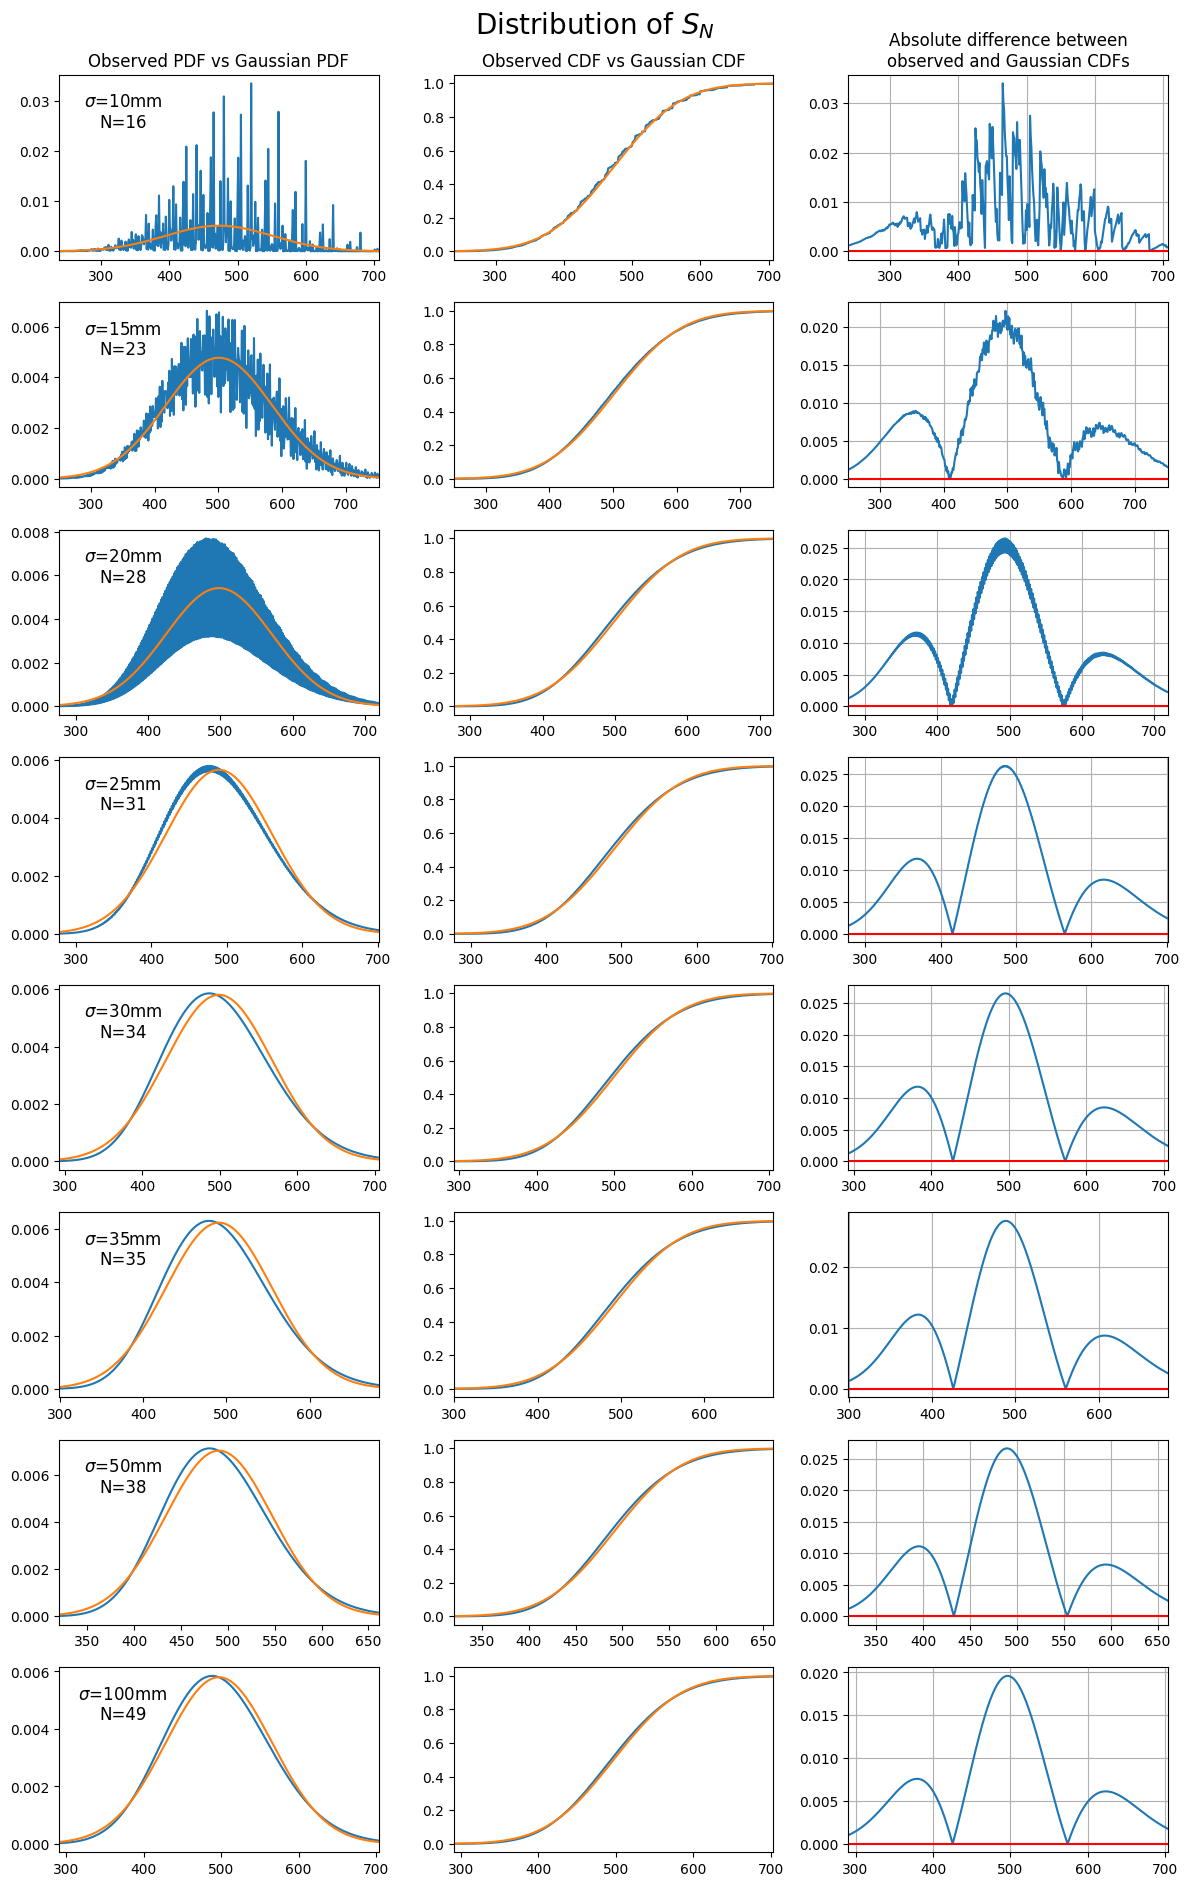

In [11]:
fig, ax = plt.subplots(nrows=8, ncols=3, figsize=(12, 8*3*0.8))
for i, sigma in enumerate([10, 15, 20, 25, 30, 35, 50, 100]):
    dist = probs_dict[sigma]
    n = int(501/EX(dist))
    plot_sum_dists(n, dist, ax[i], include_titles=i==0, label=f'$\sigma$={sigma}mm\nN={n}')
fig.suptitle('Distribution of $S_N$', fontsize=20)
fig.tight_layout()

We see here that, as expected from the CLT, the distribution of $S_N$ approaches a Gaussian distribution as $N$ increases. In fact, the difference between the observed CDF and the theoretical Gaussian CDF differ by less than 3% almost everywhere. The main differences appear to be due to the positive skewness in the underlying 1-dart distributions, which are significant particularly when $\omega$ increases in value:

In [12]:
def skew_dist(dist):
    EX3 = sum([k*k*k*v for k, v in dist.items()])
    return (EX3 - 3*EX(dist)*VarX(dist) - EX(dist)**3)/(VarX(dist)**1.5)

Text(0.5, 1.0, 'Example 1-dart distribution for $\\sigma=60$mm')

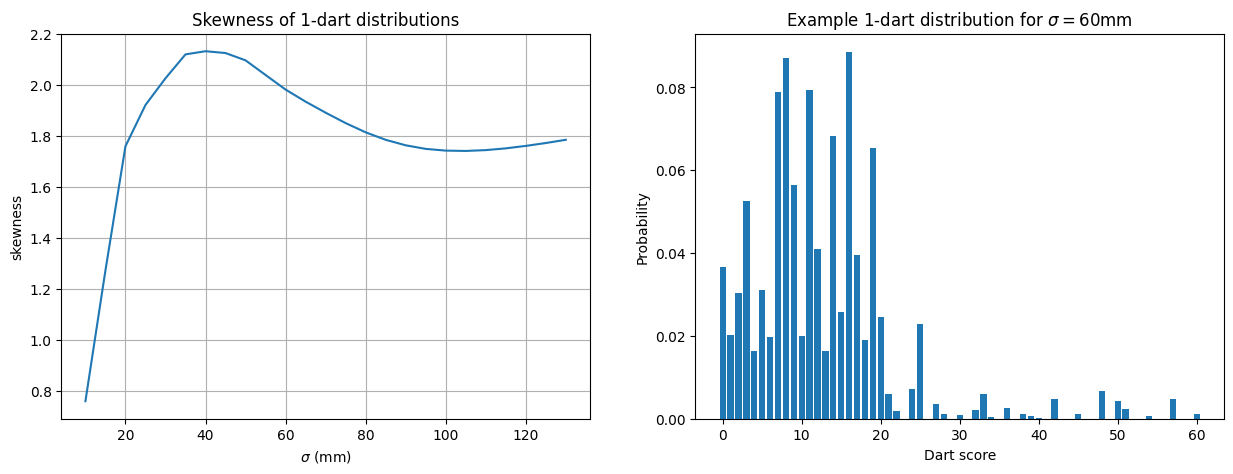

In [13]:
skews = {sigma: skew_dist(dist) for sigma, dist in probs_dict.items()}
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].plot(skews.keys(), skews.values())
ax[0].set_xlabel('$\sigma$ (mm)')
ax[0].set_ylabel('skewness')
ax[0].grid()
ax[0].set_title('Skewness of 1-dart distributions')

dist = probs_dict[60]
ax[1].bar([k for k in dist.keys()], dist.values())
ax[1].set_xlabel('Dart score')
ax[1].set_ylabel('Probability')
ax[1].set_title('Example 1-dart distribution for $\sigma=60$mm')

From these plots, it is clear that the skewness in the distribution of $X_i$ is affecting the normal approximation - even though the central limit theorem guarantees convergence in the limit. In order to adjust for the skewness, we can consider transforming the random variable $S_N$ by a monotonic increasing function $f$:

$$
\mathbf{P}\left(S_N>K\right) = \mathbf{P}\left(f(S_N) > f(K)\right).
$$

#### Choosing $f(S_N) = \sqrt{S_N}$

For example, we can find the limiting distribution of $\sqrt{S_N}$ by manipulating the central limit theorem expression for the limiting distribution of $S_N$:

$$
\begin{align}
\Phi(\alpha)=\lim_{N\rightarrow\infty}\mathbf{P}\left(\frac{S_N - N\mu}{\omega\sqrt{N}}\leq\alpha\right) &= 
\lim_{N\rightarrow\infty}\mathbf{P}\left(\frac{S_N - N\mu}{\omega\sqrt{N}}\leq \alpha + \frac{\alpha^2\omega}{4\mu\sqrt{N}}\right) \\
&= \lim_{N\rightarrow\infty}\mathbf{P}\left(S_N\leq N\mu+\alpha\omega\sqrt{N} + \frac{\alpha^2\omega^2}{4\mu}\right) \\
&= \lim_{N\rightarrow\infty}\mathbf{P}\left(S_N\leq\left(\sqrt{N\mu}+\frac{\alpha\omega}{2\sqrt{\mu}}\right)^2\right) \\
&= \lim_{N\rightarrow\infty}\mathbf{P}\left(\sqrt{S_N}\leq\sqrt{N\mu}+\frac{\alpha\omega}{2\sqrt{\mu}}\right) \\
&= \lim_{N\rightarrow\infty}\mathbf{P}\left(\frac{2\sqrt{\mu}}{\omega}\left(\sqrt{S_N} - \sqrt{N\mu}\right)\leq\alpha\right) \\
\end{align}
$$

In the first line, we add a contribution to the right hand side proportional to $N^{-1/2}\rightarrow 0$ in the limit; also, in the limit, the CDF is continuous. We also rely on the fact that $X_i\geq0$, so that the sum $S_N$ is always positive. The result is the statement that in the limit $N\rightarrow\infty$:

$$
\frac{2\sqrt{\mu}}{\omega}\left(\sqrt{S_N} - \sqrt{N\mu}\right)\rightarrow \mathcal{N}(0, 1)
$$

Can we improve this estimate? The form of this expression suggests that as $N$ grows, the mean of $\sqrt{S_N}$ behaves asymptotically like $\sqrt{N\mu}$, and the standard deviation like $\frac{\omega}{2\sqrt{\mu}}$ (i.e. constant in $N$). In fact we can find an expression for the mean with the same asymptotics, but with a greater accuracy for small values of $N$, by considering:

$$
\begin{align}
\mathbf{E}\left(\sqrt{S_N}\right)^2 &= \mathbf{E}\left(S_N\right) - \text{Var}\left(\sqrt{S_N}\right) \\
&\approx N\mu - \frac{\omega^2}{4\mu}
\end{align}
$$

Here, the limiting value of $\text{Var}(\sqrt{S_N})$ has been used to provide an approximation. Using this estimate for $\mathbf{E}\left(\sqrt{S_N}\right)$ in the formula above gives the improved result:

|Limiting distribution for $\sqrt{S_N}$|
|:--:|
| $$
\frac{2\sqrt{\mu}}{\omega}\left(\sqrt{S_N} - \sqrt{N\mu - \frac{\omega^2}{4\mu}}\right)\rightarrow \mathcal{N}(0, 1)
$$|

Let's see what the resulting observed distributions look like, compared to the theoretical limiting distribution given above:

In [14]:
def plot_sqrt_sum_dists(n, dist, ax, include_titles=False, label=False):
    sum_dist = sum_n(dist, n)
    sqrt_dist = {k**0.5: v for k, v in sum_dist.items()}
    
    ks = sorted(sqrt_dist.keys())
    vs = [sqrt_dist[k] for k in ks]
    new_ks = ks[1:]
    new_vs = np.array(vs)[1:]/np.diff(ks)
    
    mu = EX(dist)
    sig = np.sqrt(VarX(dist))
    mu_sqrt = np.sqrt(n*mu - sig*sig/(4*mu))
    sig_sqrt = sig/(2*np.sqrt(mu))
    gaussian = norm(loc=mu_sqrt, scale=sig_sqrt)
    
    # PDF plot
    x = np.linspace(mu_sqrt - 3*sig_sqrt, mu_sqrt + 3*sig_sqrt, 1000)
    ax[0].plot(new_ks, new_vs)
    ax[0].plot(x, gaussian.pdf(x))
    ax[0].set_xlim(x[0], x[-1])
    if label:
        ax[0].text(0.2, 0.8, label, horizontalalignment='center', verticalalignment='center',
              transform=ax[0].transAxes, fontsize=12)
    
    # CDF plot
    ax[1].plot(ks, np.cumsum(vs))
    ax[1].plot(x, gaussian.cdf(x))
    ax[1].set_xlim(x[0], x[-1])
    
    # Diff plot
    ax[2].plot(ks, np.abs(np.cumsum(vs) - gaussian.cdf(ks)))
    ax[2].set_xlim(x[0], x[-1])
    ax[2].grid()
    ax[2].axhline(0, c='r')
    
    if include_titles:
        ax[0].set_title('Observed PDF vs Gaussian PDF')
        ax[1].set_title('Observed CDF vs Gaussian CDF')
        ax[2].set_title('Absolute difference between\nobserved and Gaussian CDFs')

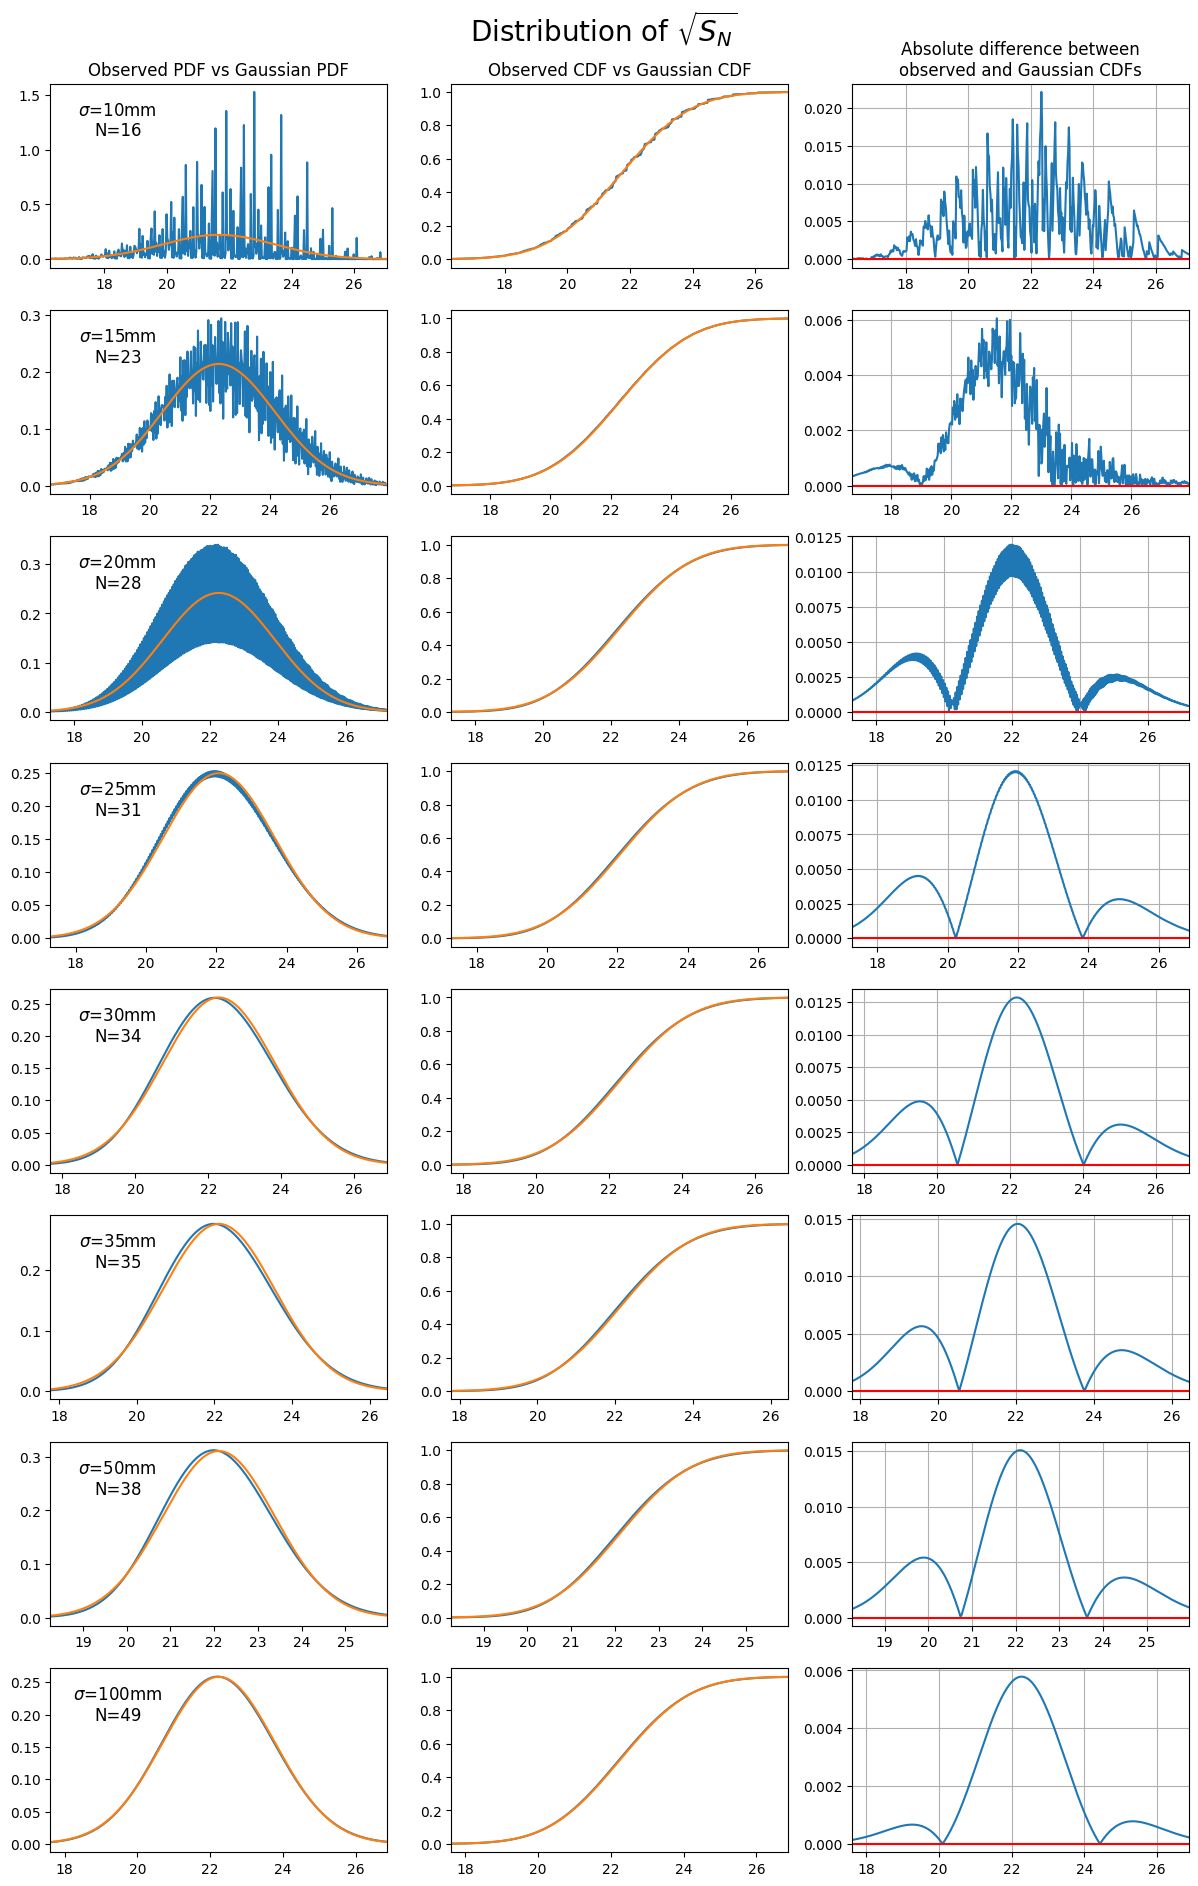

In [15]:
fig, ax = plt.subplots(nrows=8, ncols=3, figsize=(12, 8*3*0.8))
for i, sigma in enumerate([10, 15, 20, 25, 30, 35, 50, 100]):
    dist = probs_dict[sigma]
    n = int(501/EX(dist))
    plot_sqrt_sum_dists(n, dist, ax[i], include_titles=i==0, label=f'$\sigma$={sigma}mm\nN={n}')
fig.suptitle('Distribution of $\sqrt{S_N}$', fontsize=20)
fig.tight_layout()

We can see already that the transformed sum $\sqrt{S_N}$ has a reduced skewness, resulting in a closer fit to the limiting distribution for smaller $N$ - the difference between the observed and theoretical CDFs has been reduced by approximately a factor of $2$ over the standard sum $S_N$.

#### Choosing $f(S_N)=\log{S_N}$

Let's apply the same method to another function - this time, $f(X)=\log{X}$:

$$
\begin{align}
\Phi(\alpha)=\lim_{N\rightarrow\infty}\mathbf{P}\left(\frac{S_N - N\mu}{\omega\sqrt{N}}\leq\alpha\right) &= \lim_{N\rightarrow\infty}\mathbf{P}\left(S_N\leq N\mu\left(1+\frac{\alpha\omega}{\mu\sqrt{N}}\right)\right) \\
&=\lim_{N\rightarrow\infty}\mathbf{P}\left(S_N\leq N\mu\exp{\left[\frac{\alpha\omega}{\mu\sqrt{N}}\right]}\right) \\
&=\lim_{N\rightarrow\infty}\mathbf{P}\left(\log{S_N}\leq\log{N\mu} + \frac{\alpha\omega}{\mu\sqrt{N}}\right) \\
&=\lim_{N\rightarrow\infty}\mathbf{P}\left(\frac{\mu\sqrt{N}}{\omega}\left[\log{S_N} - \log{N\mu}\right]\leq\alpha\right) \\
\end{align}
$$

The second line follows, as in the limit $N\rightarrow\infty$ the In other words, as $N\rightarrow\infty$:

$$
\frac{\mu\sqrt{N}}{\omega}\left(\log{S_N} - \log{N\mu}\right)\rightarrow \mathcal{N}(0, 1)
$$

As in the previous case, this estimate can be improved by considering the expected value of $\log{S_N}$:

$$
\begin{align}
\mathbf{E}\left[\log{S_N}\right]&=\mathbf{E}\left[\log{\left(1+\frac{S_N - N\mu}{N\mu}\right)} + \log{N\mu}\right] \\
&= \mathbf{E}\left[\log{\left(1+\frac{\omega}{\mu\sqrt{N}}\frac{S_N - N\mu}{\omega\sqrt{N}}\right)} + \log{N\mu}\right] \\
\end{align}
$$

The first term inside the expectation is of the form $\log(1+x)$ with $x\rightarrow0$ as $N\rightarrow0$; this is because of the central limit theorem again:

$$
\frac{\omega}{\mu\sqrt{N}}\frac{S_N - N\mu}{\omega\sqrt{N}}\approx \mathcal{N}\left(0, \frac{\omega}{\mu\sqrt{N}}\right).
$$

This allows us to use the first couple of terms in the Taylor expansion to find a good approximation:

$$
\begin{align}
\mathbf{E}\left[\log{S_N}\right]&\approx\mathbf{E}\left[\left(\frac{S_N - N\mu}{N\mu}\right) - \frac{1}{2}\left(\frac{S_N - N\mu}{N\mu}\right)^2 + \log{N\mu}\right] \\
&=\log{N\mu}-\frac{\text{Var}\left(S_N\right)}{2\mathbf{E}\left(S_N\right)^2} \\
&=\log{N\mu}-\frac{\omega^2}{2N\mu^2}
\end{align}
$$

Substituting this back into the limiting distribution gives the following result:

|Limiting distribution for $\log{S_N}$|
|:--:|
|$$
\frac{\mu\sqrt{N}}{\omega}\left(\log{S_N} - \log{N\mu} + \frac{\omega^2}{2N\mu^2}\right)\rightarrow \mathcal{N}(0, 1)
$$|

One more time, let's look at the observed distributions of $\log{S_N}$ against the theoretical distribution suggested above:

In [16]:
def plot_log_sum_dists(n, dist, ax, include_titles=False, label=False):
    sum_dist = sum_n(dist, n)
    log_dist = {np.log(k): v for k, v in sum_dist.items()}
    
    ks = sorted(log_dist.keys())
    vs = [log_dist[k] for k in ks]
    new_ks = ks[1:]
    new_vs = np.array(vs)[1:]/np.diff(ks)
    
    mu = EX(dist)
    sig = np.sqrt(VarX(dist))
    mu_sqrt = np.log(n*mu) - sig*sig/(2*n*mu*mu)
    sig_sqrt = sig/(mu*np.sqrt(n))
    gaussian = norm(loc=mu_sqrt, scale=sig_sqrt)
    
    # PDF plot
    x = np.linspace(mu_sqrt - 3*sig_sqrt, mu_sqrt + 3*sig_sqrt, 1000)
    ax[0].plot(new_ks, new_vs)
    ax[0].plot(x, gaussian.pdf(x))
    ax[0].set_xlim(x[0], x[-1])
    if label:
        ax[0].text(0.2, 0.8, label, horizontalalignment='center', verticalalignment='center',
              transform=ax[0].transAxes, fontsize=12)
    
    # CDF plot
    ax[1].plot(ks, np.cumsum(vs))
    ax[1].plot(x, gaussian.cdf(x))
    ax[1].set_xlim(x[0], x[-1])
    
    # Diff plot
    ax[2].plot(ks, np.abs(np.cumsum(vs) - gaussian.cdf(ks)))
    ax[2].set_xlim(x[0], x[-1])
    ax[2].grid()
    ax[2].axhline(0, c='r')
    
    if include_titles:
        ax[0].set_title('Observed PDF vs Gaussian PDF')
        ax[1].set_title('Observed CDF vs Gaussian CDF')
        ax[2].set_title('Absolute difference between\nobserved and Gaussian CDFs')

C:\Users\mikey\AppData\Local\Temp\ipykernel_25236\291057168.py:3: RuntimeWarning: divide by zero encountered in log
  log_dist = {np.log(k): v for k, v in sum_dist.items()}


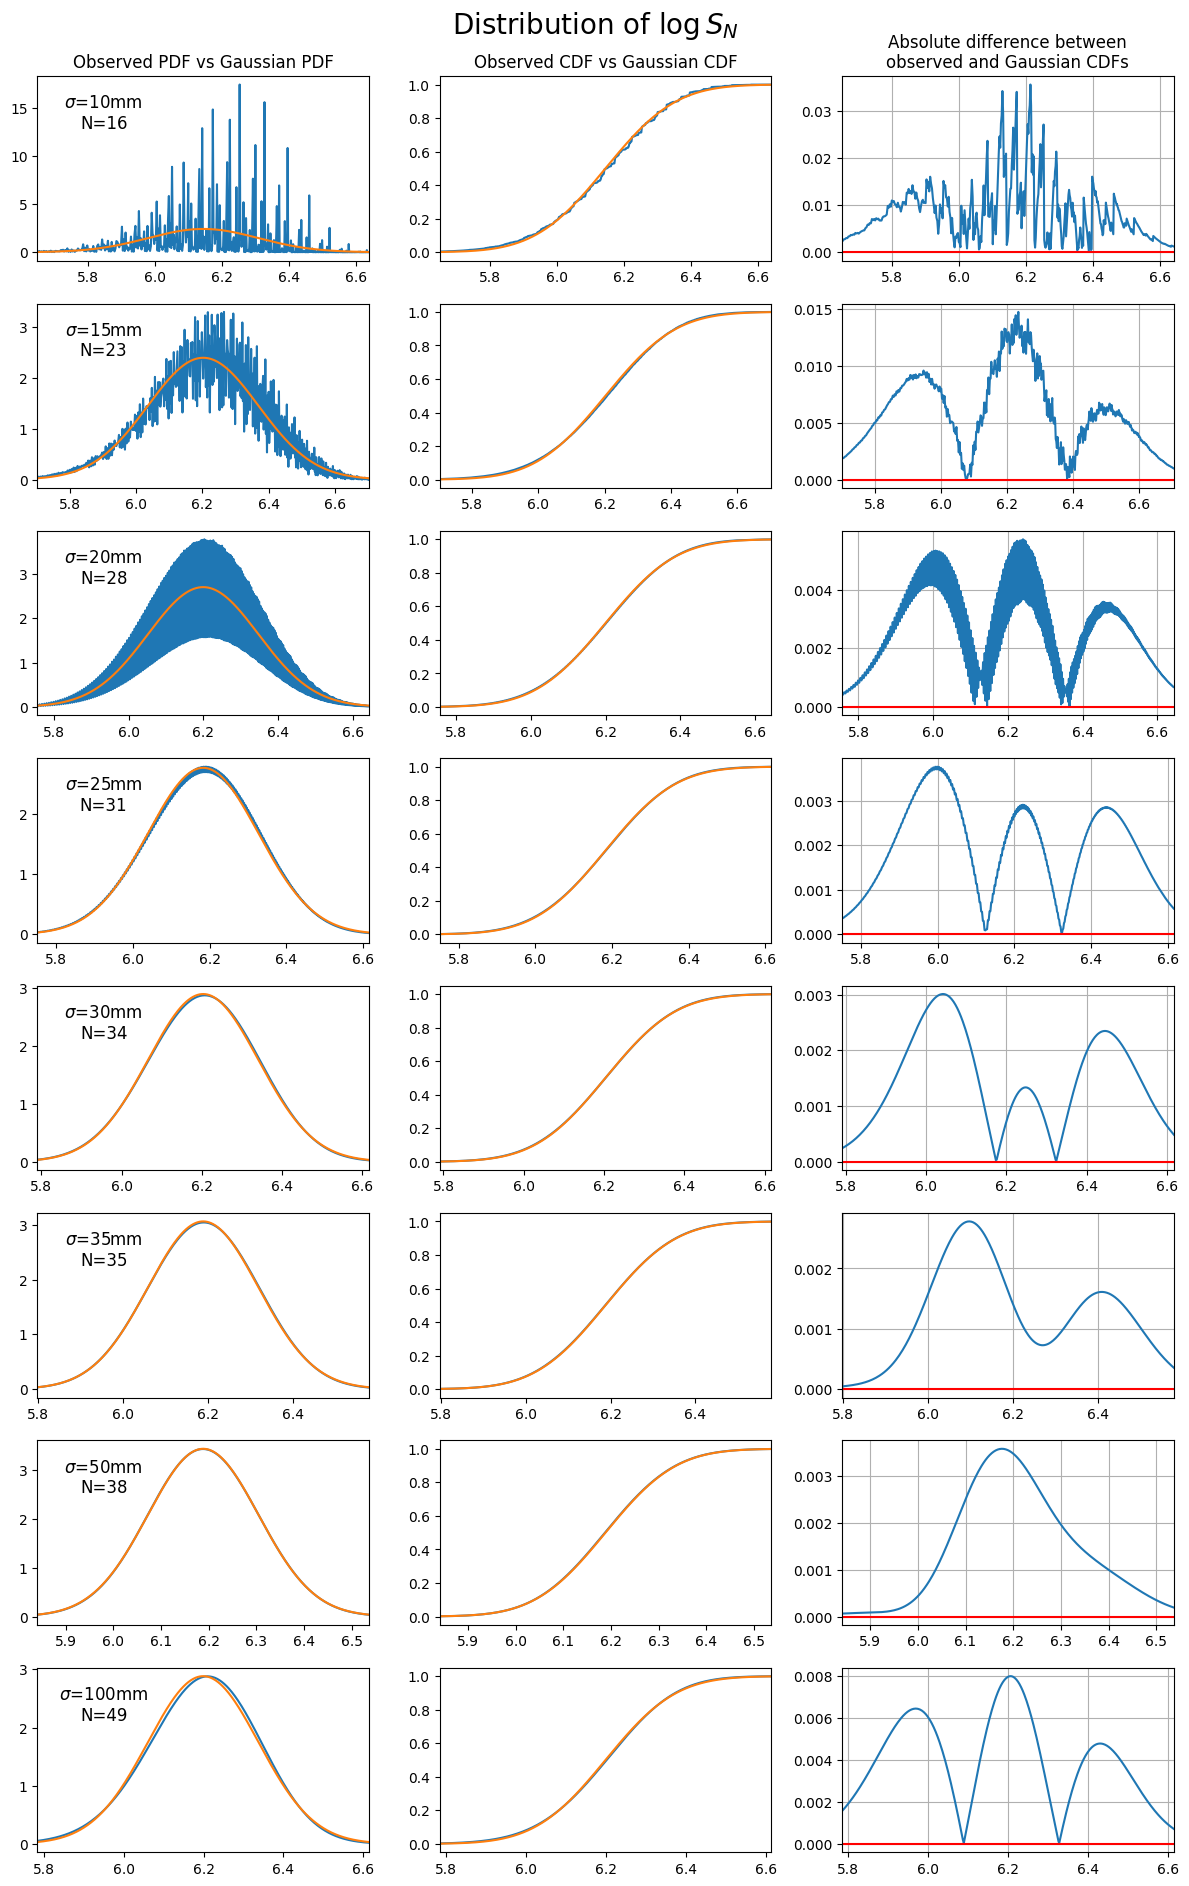

In [17]:
fig, ax = plt.subplots(nrows=8, ncols=3, figsize=(12, 8*3*0.8))
for i, sigma in enumerate([10, 15, 20, 25, 30, 35, 50, 100]):
    dist = probs_dict[sigma]
    n = int(501/EX(dist))
    plot_log_sum_dists(n, dist, ax[i], include_titles=i==0, label=f'$\sigma$={sigma}mm\nN={n}')
fig.suptitle('Distribution of $\log{S_N}$', fontsize=20)
fig.tight_layout()

This transformation provides a good fit, particularly for $\sigma>20$mm, resulting in a max CDF difference of less than 0.5%. 

#### Choosing $f(S_N)=S_N^k$

A generalization of the $f(S_N)=\sqrt{S_N}$ example is considering $f(S_N)=S_N^k$ for a general $k\in\mathbb{R}$. The analysis for the $k=\frac{1}{2}$ case is similar so I will not repeat the computations here - the result is that the limiting distribution looks like:

|Limiting distribution for ${S}_N^{k}$|
|:--:|
|$$
S_N^k\approx \mathcal{N}\left(\left(N\mu\right)^{k}\left[1 + \frac{k(k-1)\omega^2}{2N\mu^2}\right], \;\frac{k\omega\left(N\mu\right)^k}{\mu\sqrt{N}}\right)
$$|

It is straightforward to verify that the limiting distributions for $k=1$ and $k=\frac{1}{2}$ match the limiting distributions for $S_N$ and $\sqrt{S_N}$ observed earlier (at least asymptotically).

#### Comparing transformations

To see which transformations are best for different values of $\sigma$, we can find the maximum deviation between the observed and theoretical CDFs for each of the transformation choices (including the trivial one):

In [20]:
sum_abs = []
sqrt_abs = []
log_abs = []
k_abs = []
power = 0.25

for k in probs_dict.keys():
    dist = probs_dict[k]
    n = int(501/EX(dist))
    sum_dist = sum_n(dist, n)
    sum_dist = {k: sum_dist[k] for k in sorted(sum_dist.keys())}
    sqrt_dist = {k**0.5: v for k, v in sum_dist.items()}
    log_dist = {np.log(k): v for k, v in sum_dist.items()}
    k_dist = {k**power: v for k, v in sum_dist.items()}
    
    sum_ks = np.array(list(sum_dist.keys()))
    sqrt_ks = np.array(list(sqrt_dist.keys()))
    log_ks = np.array(list(log_dist.keys()))
    k_ks = np.array(list(k_dist.keys()))
    vs = np.array(list(sum_dist.values()))

    mu = EX(dist)
    sig = np.sqrt(VarX(dist))
    
    mu_sum = n*mu
    sig_sum = np.sqrt(n)*sig
    mu_sqrt = np.sqrt(n*mu - sig*sig/(4*mu))
    sig_sqrt = sig/(2*np.sqrt(mu))
    mu_log = np.log(n*mu) - sig*sig/(2*n*mu*mu)
    sig_log = sig/(mu*np.sqrt(n))
    mu_k = (n*mu)**power + 0.5*power*(power-1)*sig*sig*n**(power-1)*mu**(power-2)
    sig_k = power*sig*(n*mu)**power/(np.sqrt(n)*mu)
    
    gaussian_sum = norm(loc=mu_sum, scale=sig_sum)
    gaussian_sqrt = norm(loc=mu_sqrt, scale=sig_sqrt)
    gaussian_log = norm(loc=mu_log, scale=sig_log)
    gaussian_k = norm(loc=mu_k, scale=sig_k)
    
    sum_abs.append(max(np.abs(np.cumsum(vs) - gaussian_sum.cdf(sum_ks))))
    sqrt_abs.append(max(np.abs(np.cumsum(vs) - gaussian_sqrt.cdf(sqrt_ks))))
    log_abs.append(max(np.abs(np.cumsum(vs) - gaussian_log.cdf(log_ks))))
    k_abs.append(max(np.abs(np.cumsum(vs) - gaussian_k.cdf(k_ks))))

C:\Users\mikey\AppData\Local\Temp\ipykernel_25236\2998569172.py:13: RuntimeWarning: divide by zero encountered in log
  log_dist = {np.log(k): v for k, v in sum_dist.items()}


Text(0.5, 1.0, 'Maximum deviation between observed and theoretical CDFs')

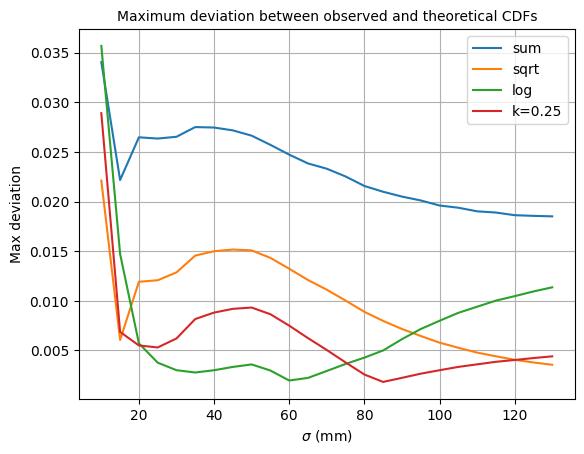

In [21]:
plt.plot(probs_dict.keys(), sum_abs, label='sum')
plt.plot(probs_dict.keys(), sqrt_abs, label='sqrt')
plt.plot(probs_dict.keys(), log_abs, label='log')
plt.plot(probs_dict.keys(), k_abs, label=f'k={power}')
plt.legend()
plt.grid()
plt.xlabel('$\sigma$ (mm)')
plt.ylabel('Max deviation')
plt.title('Maximum deviation between observed and theoretical CDFs', fontsize=10)

This plot shows that for a large range of $\sigma$ (between $20$ and $80$mm), the $\log$ transformation provides the best fit. for smaller/larger than this, a polynomial transformation performs better. Both the polynomial and $\log$ transformations perform better than the standard sum, at all $\sigma$ ranges.

#### Comparing PPFs

A final check can be made to see whether the fit for small values of $N$ is sufficiently good. Up until now, the goodness of fit has been measured by the absolute difference between the observed CDF and the CDF of the theoretical limiting distribution. Another comparison method is to evaluate the percentiles of the observed and theoretical distributions via the probability point functions (PPFs); these allow us to find the total score $z$ for which the probability of the transformed total score being less than $z$ is $p$:

$$
\text{ppf}(p) = \underset{z\in\mathbb{R}}{\text{argmax}}\left\{z : \mathbf{P}\left(f(S_N)\leq z\right)\leq p\right\}
$$

Computing this function for both the observed and theoretical distributions is useful, particularly when evaluating whether the distributions have a good match in the tails (i.e. $p=\varepsilon$ and $p=1-\varepsilon$ for $\varepsilon\ll 1$). The plot below shows the comparison for $\log{S_N}$:

In [129]:
def plot_log_sum_ppf(n, dist, ax, include_titles=False, label=False):
    sum_dist = sum_n(dist, n)
    log_dist = {np.log(k): v for k, v in sum_dist.items()}
    
    ks = sorted(log_dist.keys())
    vs = [log_dist[k] for k in ks]
    new_ks = ks[1:]
    new_vs = np.array(vs)[1:]/np.diff(ks)
    
    mu = EX(dist)
    sig = np.sqrt(VarX(dist))
    mu_sqrt = np.log(n*mu) - sig*sig/(2*n*mu*mu)
    sig_sqrt = sig/(mu*np.sqrt(n))
    gaussian = norm(loc=mu_sqrt, scale=sig_sqrt)
    
    # PDF plot
    x = np.linspace(mu_sqrt - 3*sig_sqrt, mu_sqrt + 3*sig_sqrt, 1000)
    ax[0].plot(np.exp(new_ks), new_vs)
    ax[0].plot(np.exp(x), gaussian.pdf(x))
    ax[0].set_xlim(np.exp(x[0]), np.exp(x[-1]))
    if label:
        ax[0].text(0.8, 0.8, label, horizontalalignment='center', verticalalignment='center',
              transform=ax[0].transAxes, fontsize=12)
    
    # CDF plot
    ax[1].plot(np.cumsum(vs), np.exp(ks))
    ax[1].plot(np.cumsum(vs), np.exp(gaussian.ppf(np.cumsum(vs))))
    ax[1].set_xlim(-0.02, 1.02)

    # Diff plot
    ax[2].plot(np.cumsum(vs), np.log10(np.abs(np.exp(ks) - np.exp(gaussian.ppf(np.cumsum(vs))))))
    ticks = ax[2].get_yticks()
    ax[2].set_yticks(ticks)
    ax[2].set_yticklabels([f'$10^{{{int(tick)}}}$' for tick in ticks])
    ax[2].set_xlim(-0.02, 1.02)
    ax[2].grid()
    
    if include_titles:
        ax[0].set_title('Observed PDF vs Gaussian PDF')
        ax[1].set_title('Observed PPF vs Gaussian PPF')
        ax[2].set_title('Absolute difference between\nobserved and Gaussian PPFs')

C:\Users\mikey\AppData\Local\Temp\ipykernel_25236\3510963993.py:3: RuntimeWarning: divide by zero encountered in log
  log_dist = {np.log(k): v for k, v in sum_dist.items()}
C:\Users\mikey\AppData\Local\Temp\ipykernel_25236\3510963993.py:3: RuntimeWarning: divide by zero encountered in log
  log_dist = {np.log(k): v for k, v in sum_dist.items()}
C:\Users\mikey\AppData\Local\Temp\ipykernel_25236\3510963993.py:3: RuntimeWarning: divide by zero encountered in log
  log_dist = {np.log(k): v for k, v in sum_dist.items()}
C:\Users\mikey\AppData\Local\Temp\ipykernel_25236\3510963993.py:3: RuntimeWarning: divide by zero encountered in log
  log_dist = {np.log(k): v for k, v in sum_dist.items()}
C:\Users\mikey\AppData\Local\Temp\ipykernel_25236\3510963993.py:3: RuntimeWarning: divide by zero encountered in log
  log_dist = {np.log(k): v for k, v in sum_dist.items()}
C:\Users\mikey\AppData\Local\Temp\ipykernel_25236\3510963993.py:3: RuntimeWarning: divide by zero encountered in log
  log_dist = 

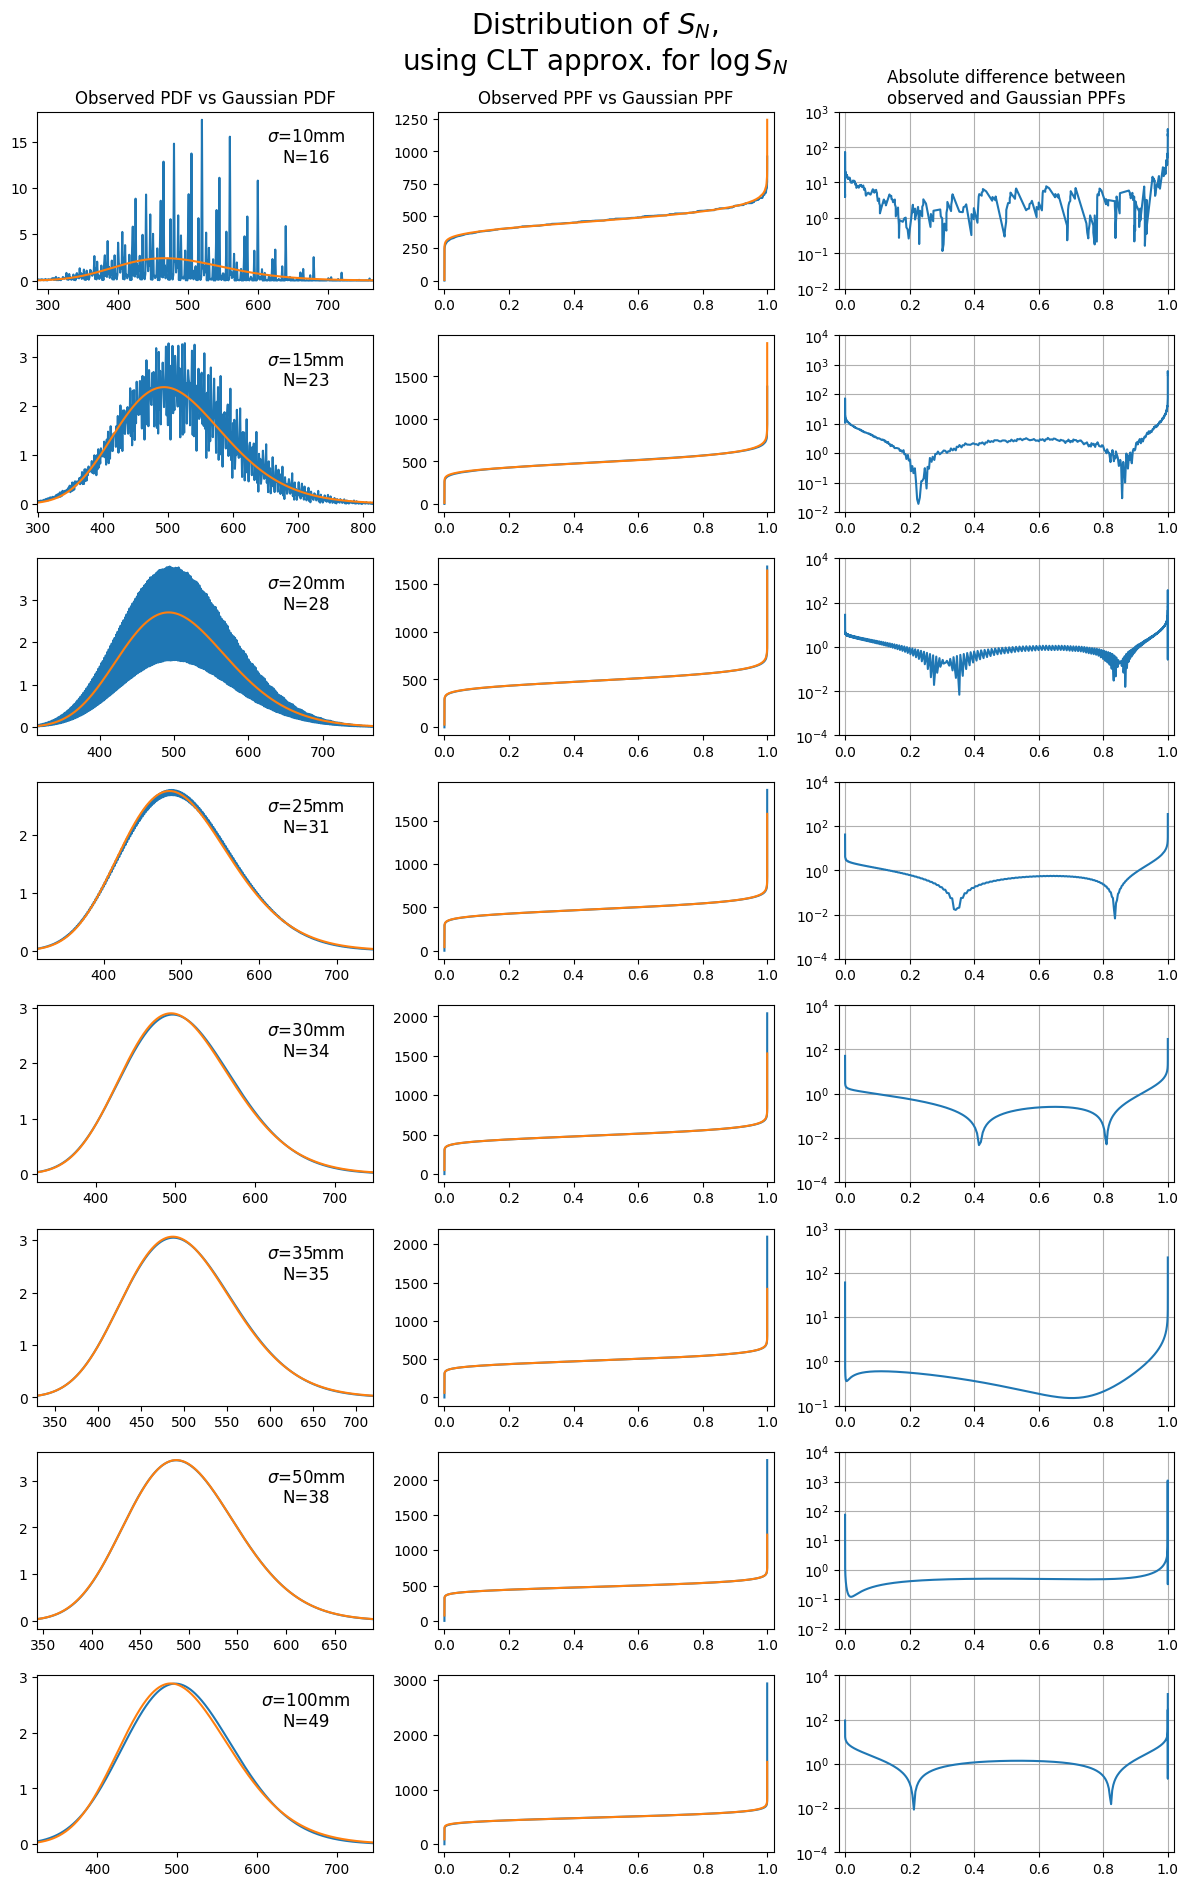

In [132]:
fig, ax = plt.subplots(nrows=8, ncols=3, figsize=(12, 8*3*0.8))
for i, sigma in enumerate([10, 15, 20, 25, 30, 35, 50, 100]):
    dist = probs_dict[sigma]
    n = int(501/EX(dist))
    plot_log_sum_ppf(n, dist, ax[i], include_titles=i==0, label=f'$\sigma$={sigma}mm\nN={n}')
fig.suptitle('Distribution of $S_N$,\nusing CLT approx. for $\log{S_N}$', fontsize=20)
fig.tight_layout()

We see that for all values of $\sigma$, and for the almost whole range of percentiles $p$, the difference between the observed and theoretical PPFs are of the order of $10^{-2}$ or smaller. In the tails, this rises to the order of $10^{-1}$ to $10^0$, which is still small enough to be able to identify specific total scores (which are confined to whole numbers) for specific percentiles.

### Sharpe ratio

We have seen that there are various ways to transform the total score $S_N$ to improve the approximation given by the central limit theorem for small $N$. However, there is an advantage to sticking with the CLT-informed approximation of a Gaussian CDF for the function $F(N, K)$, while keeping in mind the ranges of $\sigma$ and $N$ for which the assumption is reasonable. To recap, let's assume that:

$$
\mathbf{P}\left(S_N>kN\right) \approx \Phi\left[\sqrt{N}\,\frac{\mu - k}{\omega}\right]
$$

where $N$ is the number of darts thrown, and $\mu, \omega$ are the mean and standard deviation of a single dart throw (recall that $\sigma$ is fixed here). $k$ can be interpreted as a target average score from a single dart throw, that Alice is hoping to exceed. If the Alice's aim is to maximise this probability, she needs to aim at the following point on the board:

$$
p_{max}(k) = \underset{p}{\mathrm{argmax}}\left[\frac{\mu(p) - k}{\omega(p)}\right]
$$

The dependence of $\mu$ and $\omega$ on the aiming point $p$ is made explicit in this equation - changing $p$ will affect the expected scores obtained when throwing a single dart.

The formula is intriguingly reminiscent of the __Sharpe ratio__, a statistic used in quantitative finance to give a risk-adjusted measure of the performance of a portfolio or trading strategy, compared to the available risk-free rate:
- $\mu \longleftrightarrow$ return of portfolio/strategy,
- $\omega \longleftrightarrow$ volatility of portfolio/strategy,
- $k \longleftrightarrow$ available risk-free rate of return.

The maximisation of this quantity therefore has the interpretation of ensuring a high rate of return (i.e. single dart score) against a target rate of return (i.e. target average dart score), after controlling for volatility (the variance in the single dart score).

Also made explicit in the formula above is the dependence of the optimal aim point on the target value $k$. Varying the value of $k$ corresponds to selecting opponents with various skill levels. We can find how the optimal aim point $p$ varies, as the value of $k$ varies, in a similar way to earlier - this time, using the Sharpe ratio as the target function.

In [24]:
rates = [10, 15, 20, 25, 30, 35, 40, 45, 50]

sharpe_exps = {rate: [] for rate in rates}
sharpe_stds = {rate: [] for rate in rates}
sharpes = {rate: [] for rate in rates}
sharpe_coords = {rate: [] for rate in rates}

sigma_range = np.linspace(1, 70, 200)

for sigma in tqdm(sigma_range):
    sigma_pxl = sigma / mm_per_pixel
    mu = np.zeros(2)
    Sigma = sigma_pxl*sigma_pxl*np.eye(2)
    
    exp = expected_score(board, mu, Sigma, padding=200)
    std = std_score(board, mu, Sigma, padding=200)

    # Coordinates of maximum adjusted Sharpe ratio
    for rate in rates:
        sharpe = (exp - rate)/(std+0.0001)
        i, j = np.unravel_index(sharpe.argmax(), sharpe.shape)
        sharpes[rate].append(sharpe[i, j])
        sharpe_exps[rate].append(exp[i, j])
        sharpe_stds[rate].append(std[i, j])
        sharpe_coords[rate].append((j, i))

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [17:16<00:00,  5.18s/it]


In [25]:
sharpe_df = pd.DataFrame(list(zip(sigma_range,
                       *sharpes.values(),
                       *sharpe_exps.values(),
                       *sharpe_stds.values(),
                       *sharpe_coords.values())), 
              columns=['sigma',
                       *[f'sharpe_{rate}' for rate in rates],
                       *[f'exp_{rate}' for rate in rates],
                       *[f'std_{rate}' for rate in rates],
                       *[f'coords_{rate}' for rate in rates]]
             ).set_index('sigma')

for rate in rates:
    board_score = sharpe_df[f'coords_{rate}'].apply(lambda x: board[x[1], x[0]]).rename(f'score_{rate}')
    groups = (board_score.diff() != 0).cumsum().rename(f'group_{rate}')
    sharpe_df = pd.concat([sharpe_df, groups, board_score], axis=1)

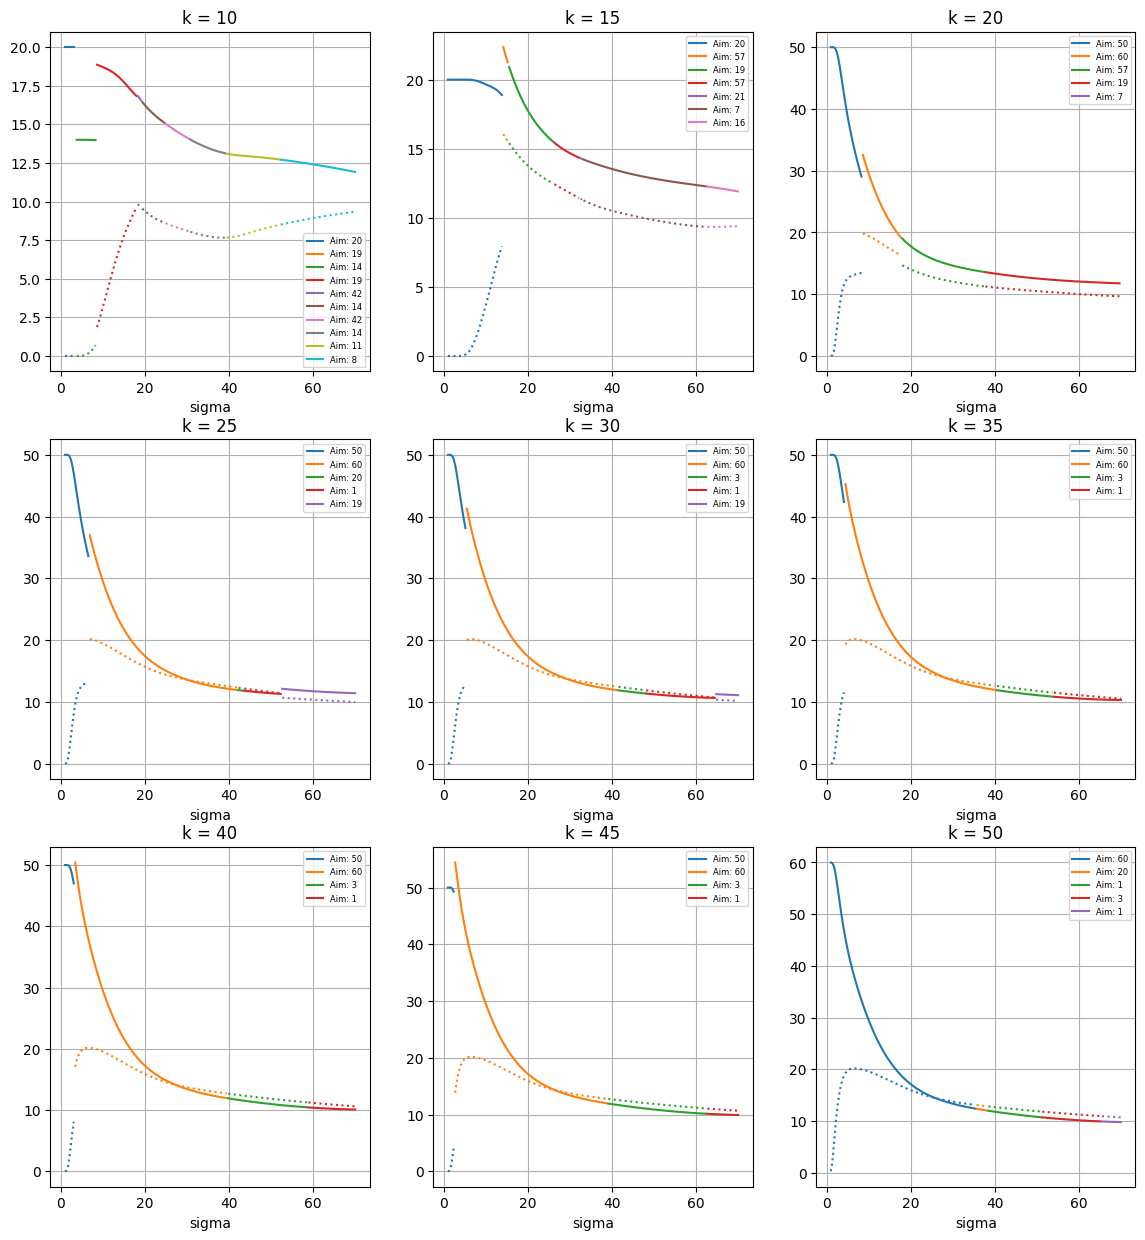

In [26]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 15))
for rate, ax in zip(rates, axes.flat):
    for group in sharpe_df[f'group_{rate}'].unique():
        color = list(TABLEAU_COLORS.values())[(group-1) % 10]
        this_df = sharpe_df[sharpe_df[f'group_{rate}'] == group]
        this_df[f'exp_{rate}'].plot(c=color, ax=ax, label=f'Aim: {int(this_df[f"score_{rate}"].iloc[0])}')
        this_df[f'std_{rate}'].plot(c=color, style=':', ax=ax, label='_nolegend_')
    ax.grid()
    ax.set_title(f'k = {rate}')
    ax.legend(prop={'size': 6})

We can also visualise the specific points on the board that Alice should aim for as her throwing distribution gets more spread, for varying values of Bob's 1-dart average $k$:

In [95]:
def board_plot(board, df, coords_col, margin, fig, ax, title):
    c = convolve2d(board, np.array([[1,1,1],[1,-8,1],[1,1,1]]), mode='same')
    c = c != 0
    x = df[coords_col].apply(lambda x: x[0])
    y = df[coords_col].apply(lambda x: x[1])
    s = df.index
    
    a = ax.scatter(x, y, c=s, cmap='autumn', s=10)
    ax.set_ylim(margin, board.shape[1]-margin)
    ax.set_xlim(margin, board.shape[0]-margin)
    ax.imshow(c)
    ax.axis('off')
    cbar = fig.colorbar(a, orientation='horizontal', pad=0.05)
    cbar.ax.set_xlabel('$\sigma$ (mm)')
    ax.set_title(title)
    return fig, ax

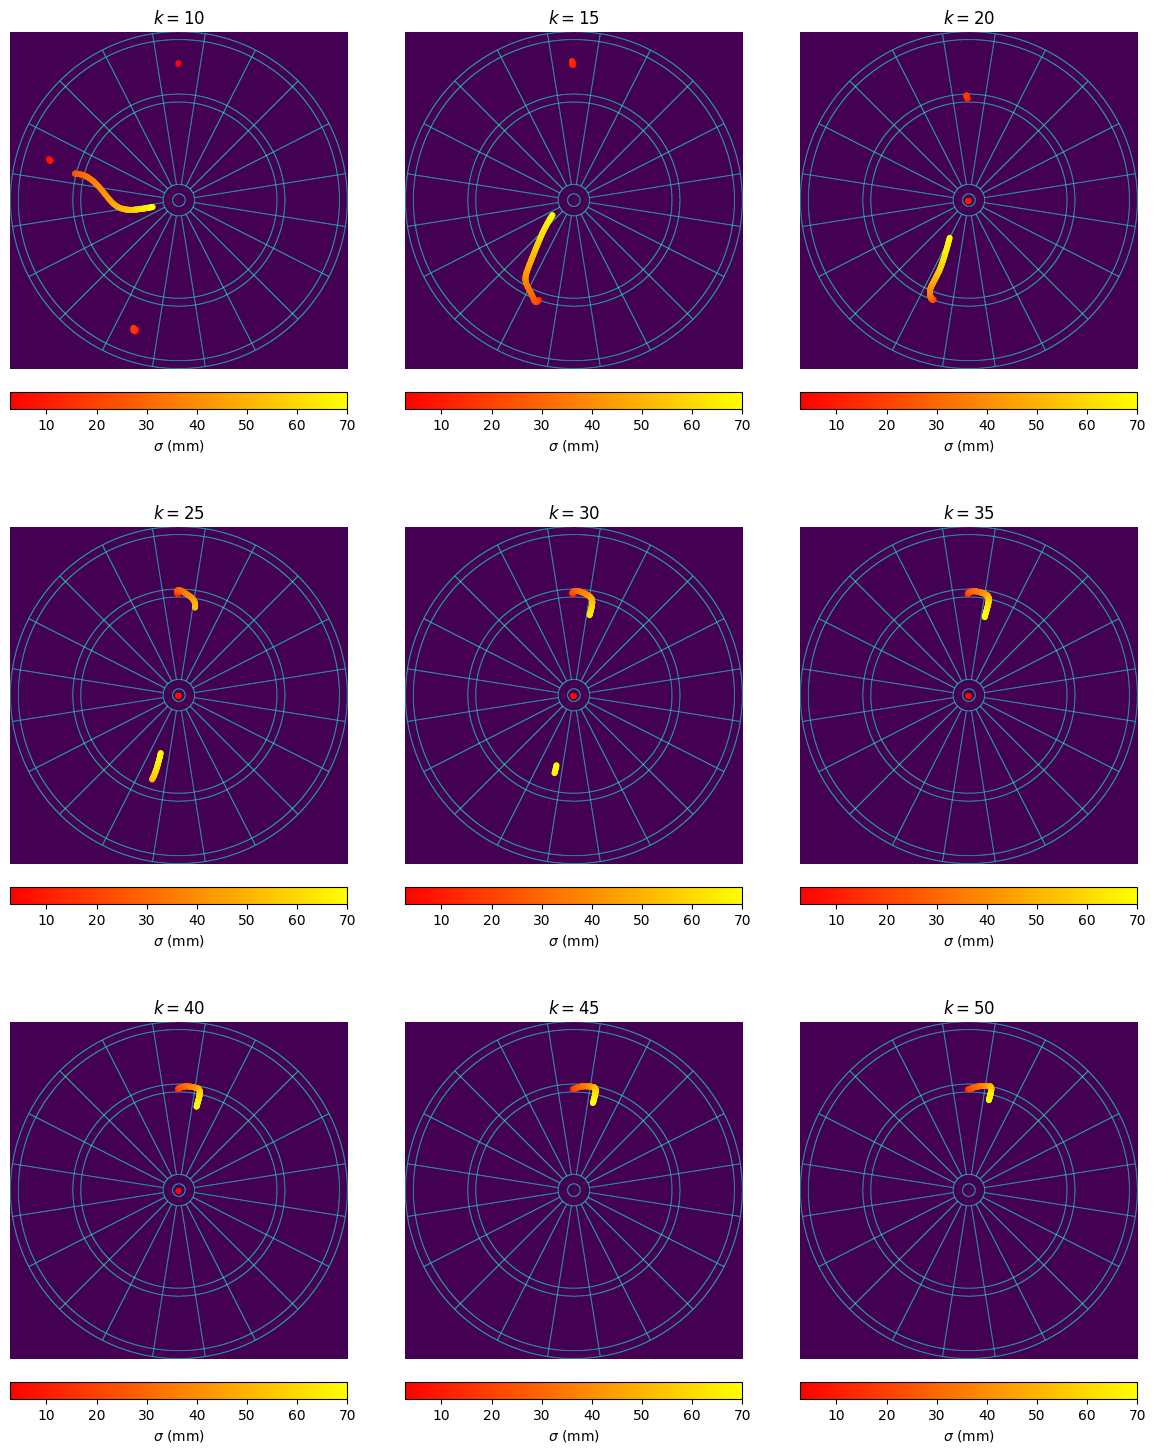

In [116]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 15))
fig.tight_layout()

for rate, ax in zip(rates, axes.flat):
    _ = board_plot(board, sharpe_df.iloc[5:], f'coords_{rate}', 250, fig=fig, ax=ax, title=f'$k={rate}$')

To explain how to interpret these plots, and describe how they might help when playing an actual game against an opponent:

- Each panel corresponds to a different choice of $k$, the average score that the opponent (Bob) scores with a single dart. So by estimating Bob's skill level (e.g. by observing average scores from previous games), Alice can work out which of these panels to refer to.


- The solid/dotted lines on the graphs give the expected score/standard deviation when aiming at the point which maximises the Sharpe ratio. Notice that for small $k$ (i.e. when Bob isn't very skillful), Alice is recommended to aim at points on the board with smaller expected value, and a smaller standard deviation; for small $k$, Alice does not need to try to maximise her raw score, but rather can focus on scoring smaller scores with higher certainties. 


- In the case that Alice has close to perfect aim, she can still reach checkout before Bob when aiming at these lower values. For $k<20$, Alice is recommended to aim for the $20$; for $20<k<45$, she is recommended to aim for the bullseye.


- For large $k$ (i.e. when Bob is very skillful), Alice needs to persue a more risky strategy in order to reach checkout at a similar time to Bob. For example, for $k>30$, Alice is recommended to always aim at (or near) the triple $20$; in the analysis focussing on just maximising expected score, Alice is recommended to switch to the triple $19$ when her throwing distribution gets too broad. This shows how the Sharpe ratio approach allows Alice to take into account her opponents skill when determining her strategy.

## Repeating for the Quadro board

How does the results of this analysis change when applied to the Quadro board, instead of the standard board? First, it is worth noting that the Central Limit Theorem approximation that allows us to use the Sharpe ratio as a sensible optimisation function is less accurate than for the standard board. This is because the 1-dart probability distribution for score is even more positively skewed, due to the presence of higher number scores from the quadruple ring adding weight to the upper tail:

In [99]:
quadro, _ = generate_dartboard(2048, quadro=True)

In [105]:
quadro_probs_dict = {}

for sigma in tqdm(sigmas):
    sigma_pxl = sigma / mm_per_pixel
    probs = clt_test(sigma_pxl, quadro, range(81))
    quadro_probs_dict[sigma] = probs

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [04:13<00:00, 10.15s/it]


Text(0.5, 1.0, 'Example 1-dart distribution for $\\sigma=60$mm')

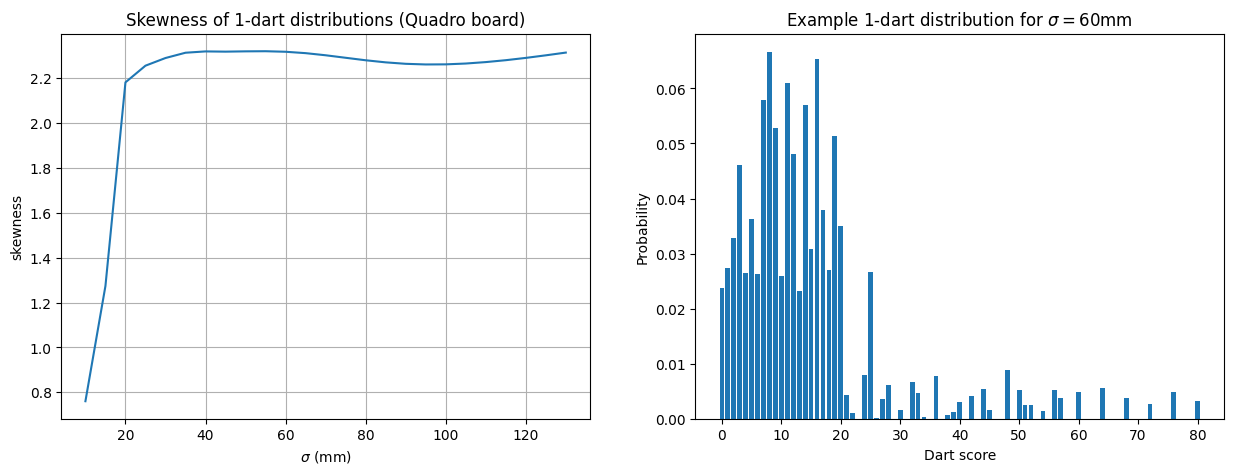

In [111]:
skews = {sigma: skew_dist(dist) for sigma, dist in quadro_probs_dict.items()}
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].plot(skews.keys(), skews.values())
ax[0].set_xlabel('$\sigma$ (mm)')
ax[0].set_ylabel('skewness')
ax[0].grid()
ax[0].set_title('Skewness of 1-dart distributions (Quadro board)')

dist = quadro_probs_dict[60]
ax[1].bar([k for k in dist.keys()], dist.values())
ax[1].set_xlabel('Dart score')
ax[1].set_ylabel('Probability')
ax[1].set_title('Example 1-dart distribution for $\sigma=60$mm')

Regardless, the theoretical limiting distribution still does a reasonable job at approximating the observed total sum, with the CDFs differing by less than $3$% for most values of $\sigma$ (in fact, the transformed sum given by $\log{S_N}$ brings the error down to less than $1%$).

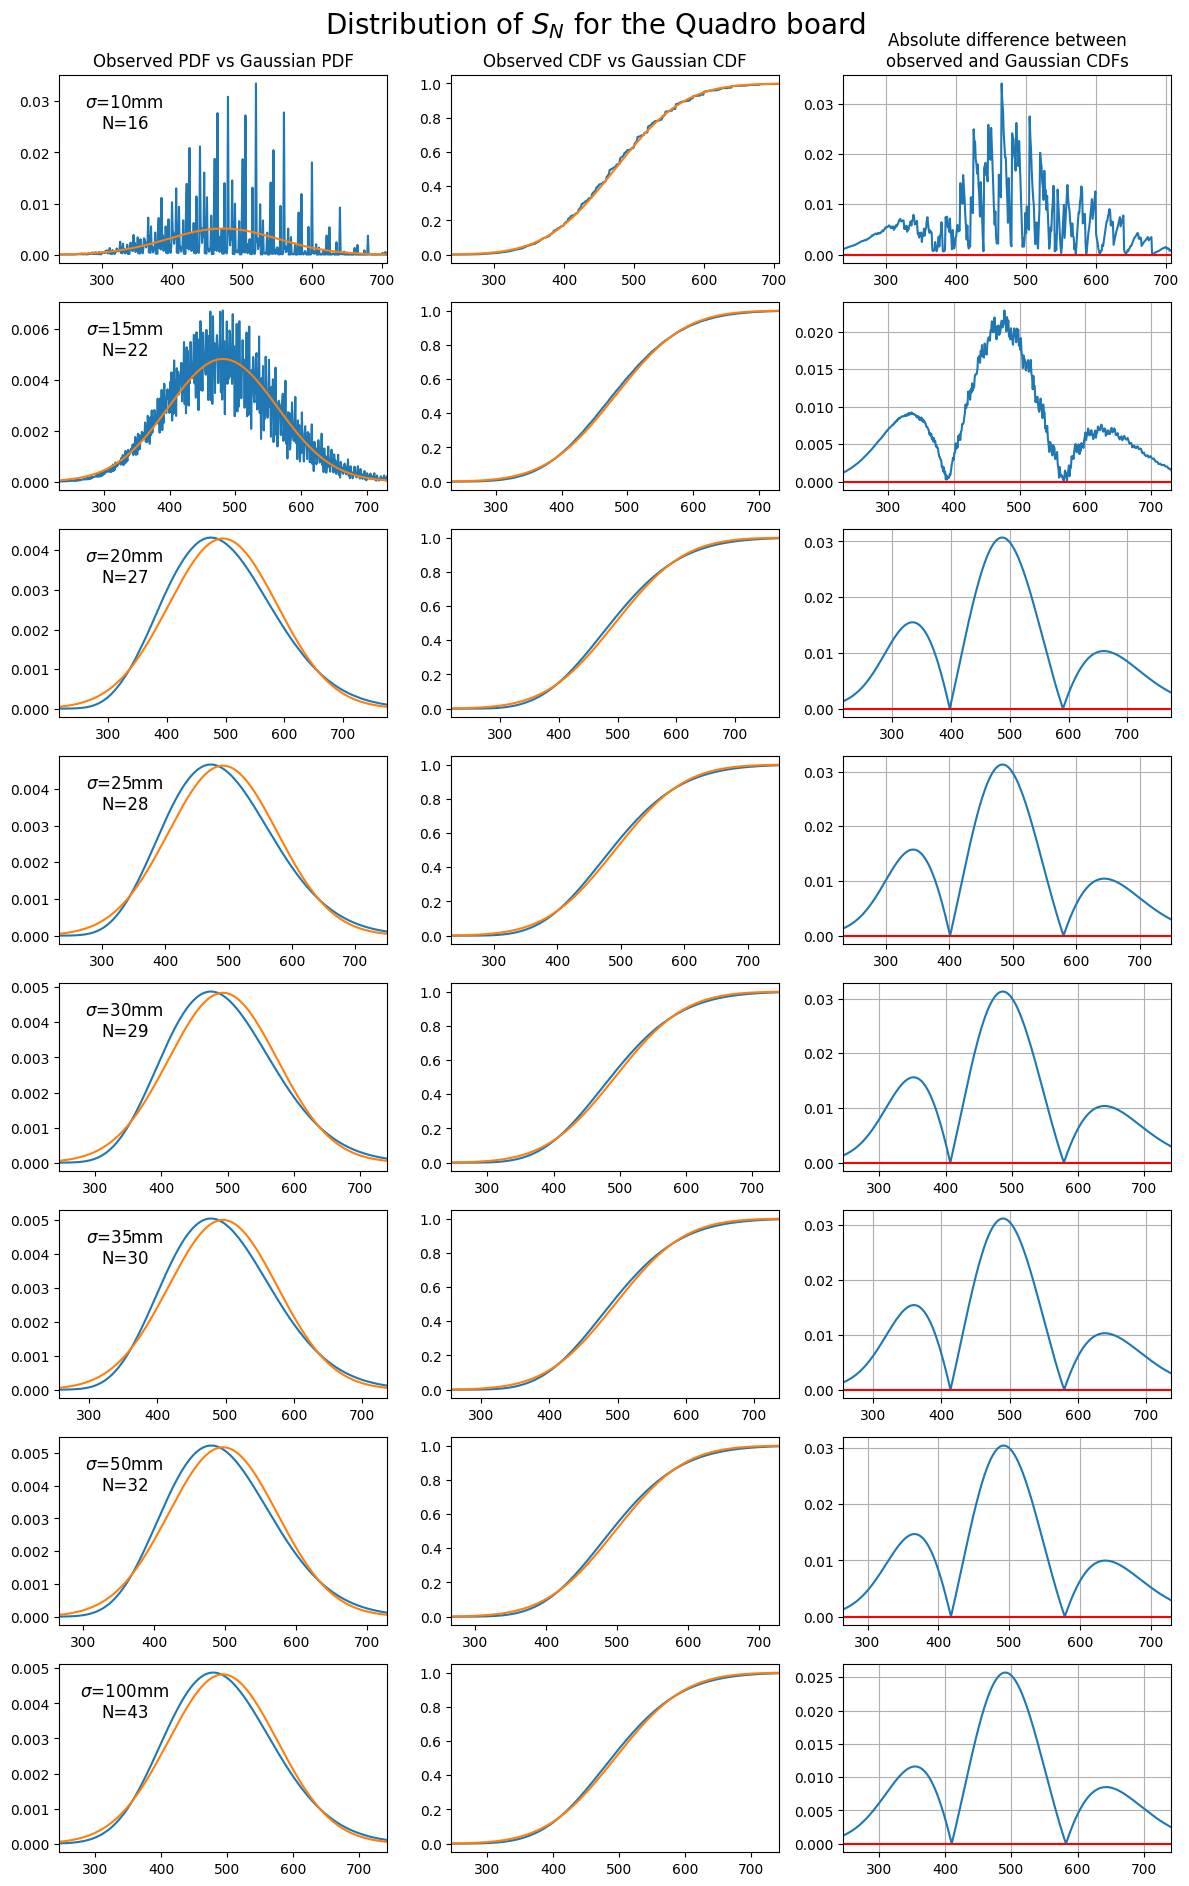

In [112]:
fig, ax = plt.subplots(nrows=8, ncols=3, figsize=(12, 8*3*0.8))
for i, sigma in enumerate([10, 15, 20, 25, 30, 35, 50, 100]):
    dist = quadro_probs_dict[sigma]
    n = int(501/EX(dist))
    plot_sum_dists(n, dist, ax[i], include_titles=i==0, label=f'$\sigma$={sigma}mm\nN={n}')
fig.suptitle('Distribution of $S_N$ for the Quadro board', fontsize=20)
fig.tight_layout()

We can visualize the optimal aim points for each value of the opponent's average 1-dart score $k$, as the throwing distribution parameter $\sigma$ ranges from $0$ up to $70$mm:

In [107]:
rates = [10, 15, 20, 25, 30, 35, 40, 45, 50]

quadro_exps = {rate: [] for rate in rates}
quadro_stds = {rate: [] for rate in rates}
quadro_sharpes = {rate: [] for rate in rates}
quadro_coords = {rate: [] for rate in rates}

sigma_range = np.linspace(1, 70, 200)

for sigma in tqdm(sigma_range):
    sigma_pxl = sigma / mm_per_pixel
    mu = np.zeros(2)
    Sigma = sigma_pxl*sigma_pxl*np.eye(2)
    
    exp = expected_score(quadro, mu, Sigma, padding=200)
    std = std_score(quadro, mu, Sigma, padding=200)

    # Coordinates of maximum adjusted Sharpe ratio
    for rate in rates:
        sharpe = (exp - rate)/(std+0.0001)
        i, j = np.unravel_index(sharpe.argmax(), sharpe.shape)
        quadro_sharpes[rate].append(sharpe[i, j])
        quadro_exps[rate].append(exp[i, j])
        quadro_stds[rate].append(std[i, j])
        quadro_coords[rate].append((j, i))

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [16:50<00:00,  5.05s/it]


In [108]:
quadro_df = pd.DataFrame(list(zip(sigma_range,
                       *quadro_sharpes.values(),
                       *quadro_exps.values(),
                       *quadro_stds.values(),
                       *quadro_coords.values())), 
              columns=['sigma',
                       *[f'sharpe_{rate}' for rate in rates],
                       *[f'exp_{rate}' for rate in rates],
                       *[f'std_{rate}' for rate in rates],
                       *[f'coords_{rate}' for rate in rates]]
             ).set_index('sigma')

for rate in rates:
    board_score = quadro_df[f'coords_{rate}'].apply(lambda x: quadro[x[1], x[0]]).rename(f'score_{rate}')
    groups = (board_score.diff() != 0).cumsum().rename(f'group_{rate}')
    quadro_df = pd.concat([quadro_df, groups, board_score], axis=1)

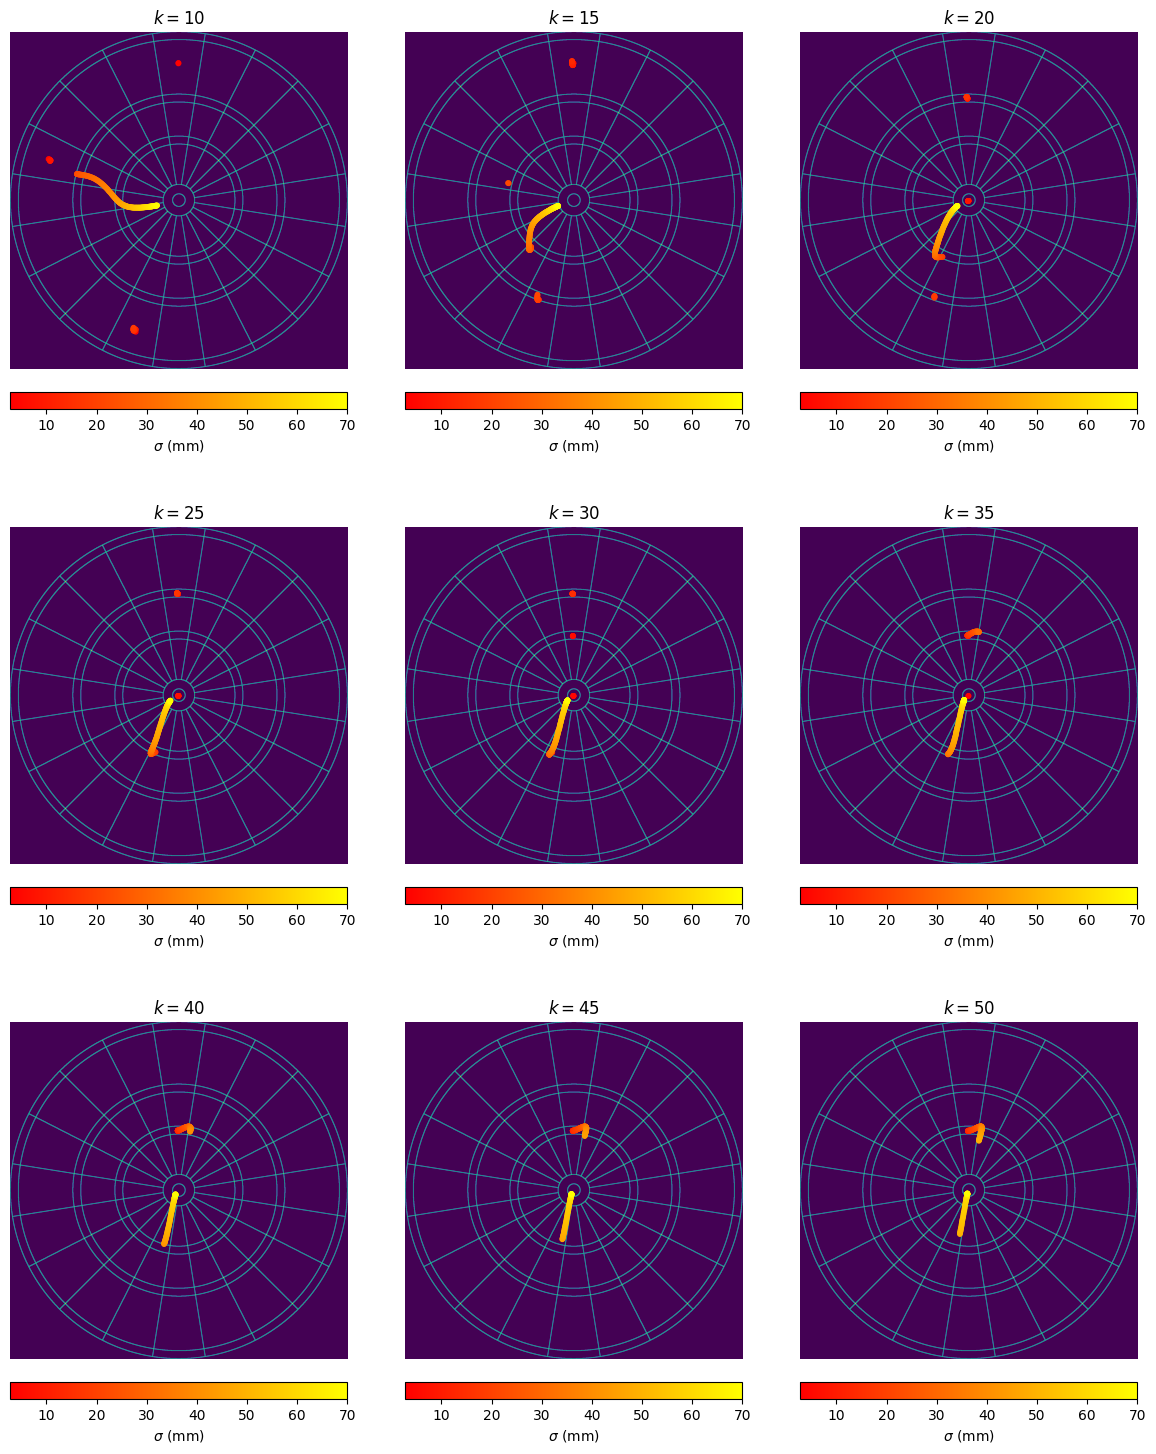

In [115]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 15))
fig.tight_layout()

for rate, ax in zip(rates, axes.flat):
    _ = board_plot(quadro, quadro_df.iloc[5:], f'coords_{rate}', 250, fig=fig, ax=ax, title=f'$k={rate}$')

The conclusions here:
- For small $k$, like for the standard board, Alice is recommended to aim for more certain areas of the board (the large single $20$ or single $19$ regions), in order to guarantee reaching the checkout stage before Bob.
- For large $k>35$ (i.e. Bob is a strong player), Alice is recommended to to aim for the quadruple $20$. This is markedly different from the expectation maximisation strategy, which quickly switches away from the quadruple $20$ to the triple $20$ for quite a small value of $\sigma$. This suggests that Alice's strategy for the Quadro board is sensitive to the estimated skill of her opponent - if she suspects Bob is at least a reasonable player, she may decide that she needs to aim for the quadruple $20$ even though the large variance in score brings down the average expected score.
- For large values of $\sigma$, the strategy is broadly similar across all opponent skill levels - aim towards the lower left part of the board, similar to the recommended location from the expectation maximisation strategy (see the previous post for details about this).

### How valuable is this analysis?

This approach has been a fun analysis that links the problem of maximizing the probability of reaching checkout within a certain number of throws to the Sharpe ratio from quant finance. It allows a slightly more advanced analysis than the simple expectation maximisation approach from the previous post, as it takes into account information about the skill level of the opponent.

However, the analysis does not yet take into account the mechanism for 'checking out' - i.e. by scoring a double. At best, this approach is useful at the start of the game when the player is looking to run down their score as quickly as possible, and reach a check-out score before their opponent does. In order to provide recommendations for the player once in checkout range, a more sophisticated approach is needed - one which doesn't treat each dart as an independent throw looking to maximise some function, but rather as part of a sequence of throws trying to checkout as quickly as possible The next post in this series looks to do exactly this.